# TXTL Runner Notebook
Run hypothesis generation, cross-check with oracle fallback, compare all free models, and plot results.


In [3]:
# Ensure notebook picks up latest local module edits
%load_ext autoreload
%autoreload 2

import importlib
import importlib.util
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import llm_client
import hypothesis_generator
import cross_check

# Explicit reloads for regular modules
importlib.reload(llm_client)
importlib.reload(hypothesis_generator)
importlib.reload(cross_check)

# Force-load iterative_generation from this workspace file path
_iter_path = Path.cwd() / 'iterative_generation.py'
_spec = importlib.util.spec_from_file_location('iterative_generation', _iter_path)
iterative_generation = importlib.util.module_from_spec(_spec)
sys.modules['iterative_generation'] = iterative_generation
_spec.loader.exec_module(iterative_generation)

DEFAULT_MODEL = llm_client.DEFAULT_MODEL
FREE_MODELS = llm_client.FREE_MODELS
generate_txtl_hypothesis = hypothesis_generator.generate_txtl_hypothesis
hypotheses_to_dataframe = hypothesis_generator.hypotheses_to_dataframe
cross_check_hypotheses = cross_check.cross_check_hypotheses
load_experiments = cross_check.load_experiments
run_hypothesis_iterations = iterative_generation.run_hypothesis_iterations

df_experiments = load_experiments()
print(f"Loaded {len(df_experiments)} experiments")
print(f"Default model: {DEFAULT_MODEL}")
print("Free models:", ', '.join(FREE_MODELS.keys()))
print("iterative_generation module:", iterative_generation.__file__)


Loaded 49 experiments
Default model: google/gemini-2.5-flash
Free models: gemini-2.5-flash, gpt-5-mini, deepseek-v3.2, grok-4.1-fast
iterative_generation module: /Users/marilynzhang/Evals/LearningEfficiency/iterative_generation.py


In [6]:
# 3) Run iterator loop for each free model (no hardcoded context)
import importlib.util
import sys
from pathlib import Path

# Force-load latest iterative_generation.py from current workspace
_iter_path = Path.cwd() / 'iterative_generation.py'
_spec = importlib.util.spec_from_file_location('iterative_generation', _iter_path)
iterative_generation = importlib.util.module_from_spec(_spec)
sys.modules['iterative_generation'] = iterative_generation
_spec.loader.exec_module(iterative_generation)
print('Using iterative_generation from:', iterative_generation.__file__)

benchmark_df, all_iterators, all_cross_checks = iterative_generation.benchmark_free_models(
    num_iterations=30,
    hypotheses_per_iteration=1,
    context=None,
    use_oracle_fallback=True,
)
benchmark_df.sort_values('best_experimental_productivity', ascending=False)


Using iterative_generation from: /Users/marilynzhang/Evals/LearningEfficiency/iterative_generation.py

############################################################
# TESTING MODEL: gemini-2.5-flash
############################################################
[Iteration 1, Model: google/gemini-2.5-flash]
[Actual model: google/gemini-2.5-flash]
[gemini-2.5-flash iter 1] Initial Baseline Experiment: oracle=0.100 mg/mL/hr
[Iteration 2, Model: google/gemini-2.5-flash]
[Actual model: google/gemini-2.5-flash]
[gemini-2.5-flash iter 2] Enhanced Energy and Chaperone Support: oracle=0.133 mg/mL/hr
[Iteration 3, Model: google/gemini-2.5-flash]


KeyboardInterrupt: 

In [ ]:
# 4) Plot benchmark results
import re
import numpy as np
import json

try:
    benchmark_df
except NameError:
    benchmark_df = pd.DataFrame()

try:
    all_cross_checks
except NameError:
    all_cross_checks = {}

if 'model' not in benchmark_df.columns:
    benchmark_df['model'] = pd.Series(dtype=str)

if 'best_experimental_productivity' not in benchmark_df.columns:
    benchmark_df['best_experimental_productivity'] = pd.Series(dtype=float)

plot_df = benchmark_df.copy()
plot_df['best_experimental_productivity'] = pd.to_numeric(plot_df['best_experimental_productivity'], errors='coerce')
plot_df = plot_df.sort_values('best_experimental_productivity', ascending=True)

# Detect arbitrary number of iteration columns: iter_<n>_best
iter_cols = [c for c in plot_df.columns if re.match(r'^iter_\d+_best$', c)]
iter_cols = sorted(iter_cols, key=lambda c: int(re.match(r'^iter_(\d+)_best$', c).group(1)))

# Load GP baseline stats if available
gp_stats_path = Path('gp_stepwise_stats.json')
gp_stats = None
if gp_stats_path.exists():
    with open(gp_stats_path) as f:
        gp_stats = json.load(f)
    print(f'Loaded GP baseline: {gp_stats["n_runs"]} runs, {gp_stats["n_total"]} queries each')

# Random baseline stats (hardcoded from 100-call run; rerun baseline cell to update)
_random_stats_hardcoded = {'n_calls': 100, 'mean': 0.2912, 'ci95_lo': 0.2706, 'ci95_hi': 0.3118}
try:
    _random_stats = random_stats
except NameError:
    _random_stats = _random_stats_hardcoded

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df['model'], plot_df['best_experimental_productivity'])
axes[0].set_title('Best Oracle Productivity by Model')
axes[0].set_xlabel('mg/mL/hr')

for _, row in plot_df.iterrows():
    y = [pd.to_numeric(row[c], errors='coerce') for c in iter_cols]
    x = list(range(1, len(iter_cols) + 1))
    axes[1].plot(x, y, marker='o', label=row['model'])

if gp_stats:
    gp_x = list(range(1, gp_stats['n_total'] + 1))
    axes[1].fill_between(gp_x, gp_stats['step_ci95_lo'], gp_stats['step_ci95_hi'],
                         alpha=0.15, color='red')
    axes[1].plot(gp_x, gp_stats['step_mean'], color='red', linestyle='--', linewidth=2,
                 label=f'GP baseline mean (n={gp_stats["n_runs"]})')

if _random_stats:
    axes[1].axhspan(_random_stats['ci95_lo'], _random_stats['ci95_hi'],
                    alpha=0.15, color='orange')
    axes[1].axhline(_random_stats['mean'], color='orange', linestyle='--', linewidth=2,
                    label=f'Random LLM mean (n={_random_stats["n_calls"]} calls, 95% CI)')

axes[1].set_xticks(list(range(1, len(iter_cols) + 1)))
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Best productivity (mg/mL/hr)')
axes[1].set_title('Best Oracle Productivity by Iteration per Model')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# 5) Plot all hypothesis productivities per iteration, with oracle optimal and CI

def _result_score(res):
    oracle = res.get('oracle_prediction')
    if oracle and oracle.get('predicted_productivity_mg_mL_hr') is not None:
        return float(oracle['predicted_productivity_mg_mL_hr'])
    return np.nan

# Load oracle metrics for CI calculation
model = json.load(open('oracle_artifacts/txtl_oracle_model.json'))
loo_rmse = model['metrics_loo']['rmse']
n = model['trained_rows']

# Oracle optimal (from the optimization cell - hardcode or compute)
oracle_optimal = 0.5184  # From optimization
t_crit = 2.011  # t(48, 0.975)
ci_margin = t_crit * loo_rmse
ci_lower = oracle_optimal - ci_margin
ci_upper = oracle_optimal + ci_margin

# Experimentally proven optimal so far
experimental_optimal = 0.42

models = list(all_cross_checks.keys())
if not models:
    print('No model cross-check data available to plot.')
else:
    ncols = 2
    nrows = int(np.ceil(len(models) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), squeeze=False)

    for idx, model_name in enumerate(models):
        ax = axs[idx // ncols][idx % ncols]
        iter_results = all_cross_checks[model_name]

        ax.axhspan(ci_lower, ci_upper, alpha=0.15, color='green', label=f'Oracle optimal 95% CI')
        ax.axhline(oracle_optimal, color='green', linestyle='--', linewidth=2, label=f'Oracle optimal ({oracle_optimal:.3f})')
        ax.axhline(experimental_optimal, color='grey', linestyle='-', linewidth=1.5, label=f'Experimental optimal ({experimental_optimal})')

        if gp_stats:
            gp_x = list(range(1, gp_stats['n_total'] + 1))
            ax.fill_between(gp_x, gp_stats['step_ci95_lo'], gp_stats['step_ci95_hi'],
                            alpha=0.12, color='red')
            ax.plot(gp_x, gp_stats['step_mean'], color='red', linestyle='--', linewidth=1.5,
                    label=f'GP baseline (n={gp_stats["n_runs"]})')

        if _random_stats:
            ax.axhspan(_random_stats['ci95_lo'], _random_stats['ci95_hi'],
                       alpha=0.12, color='orange')
            ax.axhline(_random_stats['mean'], color='orange', linestyle='--', linewidth=1.5,
                       label=f'Random LLM mean (n={_random_stats["n_calls"]})')

        best_x = []
        best_y = []
        for iter_num, round_results in enumerate(iter_results, start=1):
            ys = [_result_score(r) for r in round_results]
            ys = [y for y in ys if not np.isnan(y)]
            if not ys:
                continue
            x = [iter_num] * len(ys)
            ax.scatter(x, ys, alpha=0.6, s=25, color='blue')
            best = max(ys)
            best_x.append(iter_num)
            best_y.append(best)

        if best_x:
            ax.plot(best_x, best_y, color='black', linewidth=2, marker='o', label='Best each iteration')

        ax.set_title(model_name)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Oracle Productivity (mg/mL/hr)')
        ax.set_xlim(0.5, len(iter_results) + 0.5)
        ax.grid(alpha=0.2)
        ax.legend(loc='best', fontsize=7)

    total_axes = nrows * ncols
    for idx in range(len(models), total_axes):
        axs[idx // ncols][idx % ncols].axis('off')

    plt.tight_layout()
    plt.show()

print(f'Oracle optimal: {oracle_optimal:.4f} mg/mL/hr')
print(f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
print(f'Experimental optimal so far: {experimental_optimal} mg/mL/hr')


# Analysis of Feedback Uptake 

Categorical oracle-optimal values (within hypothesis generator vocabulary):
  energy_source    optimal='3-PGA'               ranking: 3-PGA (+0.0240)
  extract_type     optimal='KC6'                 ranking: KC6 (+0.0436), wild-type (-0.0445)
  chaperones       optimal='combined'            ranking: combined (+0.0285), DnaK/DnaJ/GrpE (+0.0055), GroES/EL (-0.0142), none (-0.0509)
  reaction_mode    optimal='semi-continuous'     ranking: semi-continuous (+0.0694), microfluidic (-0.0534), batch (-0.1134)

Extracted 120 hypotheses from 4 models

BEHAVIORAL FEEDBACK INCORPORATION  (iterations 2+)

  exploitation_score = fraction of scoreable parameter changes that were constructive.
  Numeric: constructive = moved in direction oracle coefficient rewards.
  Categorical (0/1): constructive = moved to oracle-optimal value (0→1).
  0→0 categorical changes (both non-optimal) are excluded from the denominator.
  score_improvement = this hypothesis's oracle score minus prior iteration best.

Model

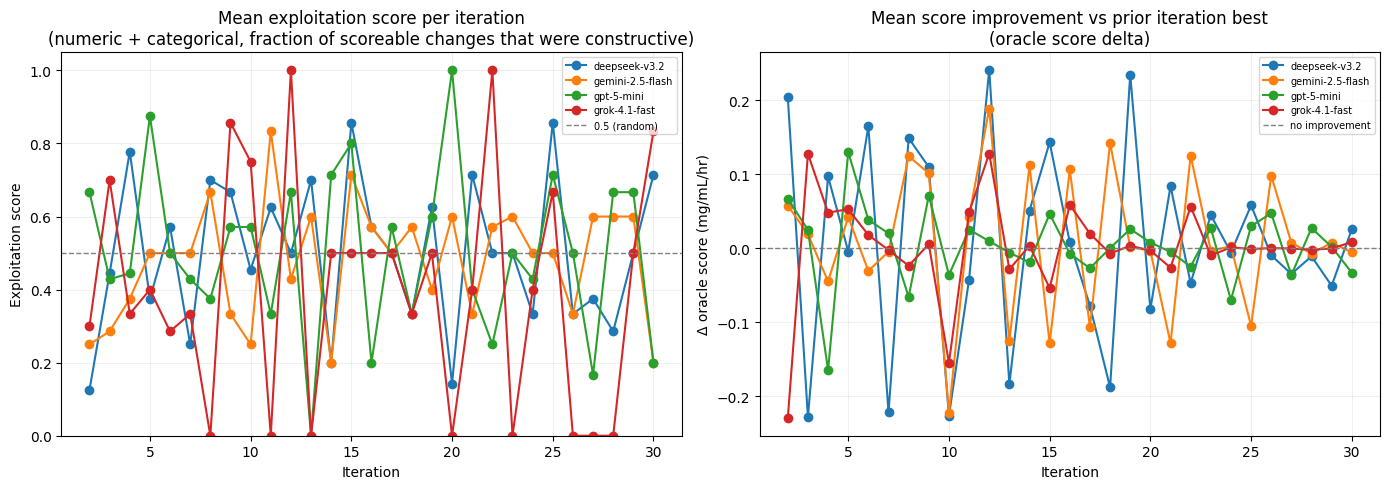

EXAMPLES — HIGHEST EXPLOITATION SCORE (most constructive parameter changes)

  Model: gpt-5-mini  |  Iteration 20  |  exploit=1.00  |  n_changed=4
  Prior best:  KC6 cold plasmid boost  |  oracle=0.3849 mg/mL/hr
  Current:     KC6 low-temp high-plasmid  |  oracle=0.3925 mg/mL/hr  |  Δ=+0.0076

  Parameter                                Prior           Current    Oracle optimal  Change
  -----------------------------------------------------------------------------------------------
  Mg_glutamate_mM                          5.000             5.200             6.000    +0.200  ✓ (↑ better)
  K_glutamate_mM                          76.000            74.000            80.000    -2.000  ✓ (↓ better)
  DTT_mM                                   0.500             0.600             0.000    +0.100  ✓ (↑ better)
  NTP_multiplier                           2.900             2.700             3.000    -0.200  ✓ (↓ better)
  PEG_8000_percent                         0.200             0.200            

In [4]:
# 10) Rationale Analysis: Feedback incorporation, parameter convergence, and performance correlation
import re
import json
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# Load oracle model and derive optimal values for all features.
# ─────────────────────────────────────────────────────────────────────────────
_oracle_model = json.load(open('oracle_artifacts/txtl_oracle_model.json'))
_numeric_features = _oracle_model['numeric_features']
_categorical_features = _oracle_model['categorical_features']
_coeffs = np.array(_oracle_model['coefficients'])
_categories = _oracle_model['preprocessor']['categories']

# Numeric: coefficient sign tells us which direction is better
COEFF_SIGN = {col: float(_coeffs[i]) for i, col in enumerate(_numeric_features)}

# Numeric optimal values
NUMERIC_OPTIMAL_PARAMS = {
    'Mg_glutamate_mM': 6.0,
    'K_glutamate_mM': 80.0,
    'DTT_mM': 0.0,
    'NTP_multiplier': 3.0,
    'PEG_8000_percent': 5.0,
    'temperature_C': 30,
    'plasmid_concentration_nM': 10.0,
}

# Vocabulary the hypothesis generator can actually produce (case-insensitive keys).
# The oracle was trained on historical data with different/extra categories
# (e.g. 'dialysis/two-stage', 'missing', 'a19') that the LLM will never generate.
# We restrict the optimal lookup to this vocabulary so we're scoring fairly.
_HYP_GEN_VOCAB = {
    'energy_source': ['3-PGA', '3-PGA + maltose', '3-PGA + maltodextrin'],
    'extract_type':  ['wild-type', 'KC6'],
    'chaperones':    ['none', 'GroES/EL', 'DnaK/DnaJ/GrpE', 'combined'],
    'reaction_mode': ['batch', 'semi-continuous', 'microfluidic'],
}

# Derive optimal categorical value: for each feature pick the vocab option whose
# oracle category (case-insensitive match) has the highest coefficient.
# If a vocab option doesn't appear in the oracle's categories at all, skip it.
def _derive_categorical_optimals():
    idx = len(_numeric_features)
    cat_coeff_map = {}  # feat → {oracle_cat_lower: coeff}
    for feat in _categorical_features:
        cats = _categories[feat]
        cat_coeffs = _coeffs[idx:idx + len(cats)]
        cat_coeff_map[feat] = {c.lower(): float(v) for c, v in zip(cats, cat_coeffs)}
        idx += len(cats)

    optimals = {}
    coeff_tables = {}
    for feat, vocab in _HYP_GEN_VOCAB.items():
        scored = []
        for v in vocab:
            coeff = cat_coeff_map.get(feat, {}).get(v.lower())
            if coeff is not None:
                scored.append((v, coeff))
        if scored:
            optimals[feat] = max(scored, key=lambda x: x[1])[0]
        coeff_tables[feat] = scored
    return optimals, coeff_tables

CATEGORICAL_OPTIMAL_PARAMS, _CAT_COEFF_TABLES = _derive_categorical_optimals()

ORACLE_OPTIMAL_PARAMS = NUMERIC_OPTIMAL_PARAMS  # kept for convergence fn backward compat

print("Categorical oracle-optimal values (within hypothesis generator vocabulary):")
for feat, val in CATEGORICAL_OPTIMAL_PARAMS.items():
    scored = sorted(_CAT_COEFF_TABLES[feat], key=lambda x: x[1], reverse=True)
    ranking = ', '.join(f'{v} ({c:+.4f})' for v, c in scored)
    print(f"  {feat:15s}  optimal={val!r:20s}  ranking: {ranking}")

# ─────────────────────────────────────────────────────────────────────────────
# Text-based signals (kept as a baseline; see behavioral metrics below)
# ─────────────────────────────────────────────────────────────────────────────
PRIOR_RESULT_WORDS = [
    'previous', 'prior', 'earlier', 'last iteration', 'last round',
    'avoid', 'showed', 'shown', 'indicated', 'based on', 'from the result',
    'given that', 'since the', 'outperformed', 'underperformed',
]
NUMERIC_SCORE_RE = re.compile(r'\b0\.\d+\s*(mg|ml|mg/ml)', re.IGNORECASE)


def _feedback_signals(rationale: str) -> dict:
    r = rationale.lower()
    prior_hits = [w for w in PRIOR_RESULT_WORDS if w in r]
    numeric_hit = bool(NUMERIC_SCORE_RE.search(rationale))
    return {
        'prior_result_words': prior_hits,
        'has_numeric_score': numeric_hit,
        'has_feedback_reference': bool(prior_hits or numeric_hit),
    }


def _behavioral_metrics(hyp, prev_best_hyp, oracle_pred, prev_best_score):
    """
    Compare hyp to the best hypothesis from the previous iteration.

    exploitation_score: fraction of scoreable parameter changes that were constructive.
      - Numeric: constructive = moved in the direction the oracle coefficient rewards.
      - Categorical (0/1): constructive = 0→1 (moved to oracle-optimal value),
        destructive = 1→0. A 0→0 change (string changed but neither is optimal)
        is noted but excluded from the denominator.

    score_improvement: oracle_pred - prev_best_score.
    """
    score_improvement = np.nan
    exploitation_score = np.nan
    n_changed = 0
    n_constructive = 0
    n_destructive = 0
    param_details = {}

    if oracle_pred is not None and prev_best_score is not None:
        score_improvement = oracle_pred - prev_best_score

    if prev_best_hyp is not None:
        # ── Numeric params ────────────────────────────────────────────────
        for param in NUMERIC_OPTIMAL_PARAMS:
            try:
                curr_val = float(hyp.get(param))
                prev_val = float(prev_best_hyp.get(param))
            except (TypeError, ValueError):
                continue
            delta = curr_val - prev_val
            sign = COEFF_SIGN.get(param, 0)
            if abs(delta) < 1e-9:
                param_details[param] = {'prev': prev_val, 'curr': curr_val, 'delta': 0.0, 'constructive': None}
                continue
            n_changed += 1
            constructive = (sign * delta) > 0
            n_constructive += constructive
            n_destructive += not constructive
            param_details[param] = {
                'prev': prev_val, 'curr': curr_val,
                'delta': delta, 'constructive': constructive,
            }

        # ── Categorical params (0/1 encoding) ────────────────────────────
        for param, optimal in CATEGORICAL_OPTIMAL_PARAMS.items():
            prev_str = str(prev_best_hyp.get(param, ''))
            curr_str = str(hyp.get(param, ''))
            prev_is_opt = prev_str.lower() == optimal.lower()
            curr_is_opt = curr_str.lower() == optimal.lower()
            string_changed = prev_str.lower() != curr_str.lower()
            delta_01 = int(curr_is_opt) - int(prev_is_opt)  # -1, 0, or +1

            if delta_01 == 0 and not string_changed:
                constructive = None  # unchanged
            elif delta_01 == 0 and string_changed:
                constructive = None  # 0→0 lateral, excluded from denominator
            else:
                n_changed += 1
                constructive = delta_01 > 0
                n_constructive += constructive
                n_destructive += not constructive

            param_details[param] = {
                'prev': prev_str, 'curr': curr_str,
                'prev_is_opt': prev_is_opt, 'curr_is_opt': curr_is_opt,
                'string_changed': string_changed,
                'constructive': constructive,
            }

        exploitation_score = (n_constructive / n_changed) if n_changed > 0 else np.nan

    return {
        'score_improvement_vs_prior_best': score_improvement,
        'exploitation_score': exploitation_score,
        'n_params_changed': n_changed,
        'n_constructive_changes': n_constructive,
        'n_destructive_changes': n_destructive,
        'param_change_details': param_details,
    }


def extract_data(all_iterators, all_cross_checks):
    """
    Build a per-hypothesis DataFrame.
    - Iteration/position derived from all_cross_checks — robust to any batch size.
    - Behavioral metrics compare each hypothesis to the best from the prior iteration.
    - curr_{param} and prev_{param} columns stored for both numeric and categorical params.
    """
    rows = []
    for model_name, iterator in all_iterators.items():
        cross_checks = all_cross_checks[model_name]

        iter_batches = []
        hyp_offset = 0
        for iter_idx, round_results in enumerate(cross_checks):
            batch = []
            for position in range(len(round_results)):
                hyp_idx = hyp_offset + position
                if hyp_idx >= len(iterator.all_hypotheses):
                    break
                hyp = iterator.all_hypotheses[hyp_idx]
                oracle_obj = round_results[position].get('oracle_prediction')
                score = oracle_obj.get('predicted_productivity_mg_mL_hr') if oracle_obj else None
                batch.append((hyp, score))
            iter_batches.append(batch)
            hyp_offset += len(round_results)

        hyp_offset = 0
        for iter_idx, round_results in enumerate(cross_checks):
            iter_num   = iter_idx + 1
            batch_size = len(round_results)

            prev_best_hyp   = None
            prev_best_score = None
            if iter_idx > 0:
                scored = [(h, s) for h, s in iter_batches[iter_idx - 1] if s is not None]
                if scored:
                    prev_best_hyp, prev_best_score = max(scored, key=lambda x: x[1])

            for position in range(batch_size):
                hyp_idx = hyp_offset + position
                if hyp_idx >= len(iterator.all_hypotheses):
                    break
                hyp = iterator.all_hypotheses[hyp_idx]
                oracle_pred = (iter_batches[iter_idx][position][1]
                               if position < len(iter_batches[iter_idx]) else None)

                rationale = str(hyp.get('rationale', ''))
                fb = _feedback_signals(rationale)

                param_distances = {}
                for param, opt in NUMERIC_OPTIMAL_PARAMS.items():
                    val = hyp.get(param)
                    try:
                        param_distances[f'{param}_distance'] = abs(float(val) - float(opt))
                    except (TypeError, ValueError):
                        param_distances[f'{param}_distance'] = np.nan

                beh = _behavioral_metrics(hyp, prev_best_hyp, oracle_pred, prev_best_score)

                curr_params, prev_params = {}, {}
                for param in NUMERIC_OPTIMAL_PARAMS:
                    try:
                        curr_params[f'curr_{param}'] = float(hyp.get(param))
                    except (TypeError, ValueError):
                        curr_params[f'curr_{param}'] = np.nan
                    if prev_best_hyp is not None:
                        try:
                            prev_params[f'prev_{param}'] = float(prev_best_hyp.get(param))
                        except (TypeError, ValueError):
                            prev_params[f'prev_{param}'] = np.nan
                for param in CATEGORICAL_OPTIMAL_PARAMS:
                    curr_params[f'curr_{param}'] = str(hyp.get(param, ''))
                    if prev_best_hyp is not None:
                        prev_params[f'prev_{param}'] = str(prev_best_hyp.get(param, ''))

                rows.append({
                    'model': model_name,
                    'iteration': iter_num,
                    'position': position,
                    'hypothesis_name': hyp.get('hypothesis_name', ''),
                    'prev_best_name': prev_best_hyp.get('hypothesis_name', '') if prev_best_hyp else None,
                    'rationale': rationale,
                    'oracle_prediction': oracle_pred,
                    'prev_best_score': prev_best_score,
                    'avg_param_distance': np.nanmean(list(param_distances.values())),
                    **fb,
                    **{k: v for k, v in beh.items() if k != 'param_change_details'},
                    'param_change_details': beh['param_change_details'],
                    **param_distances,
                    **curr_params,
                    **prev_params,
                })

            hyp_offset += batch_size

    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────────────────────
# Print functions
# ─────────────────────────────────────────────────────────────────────────────

def _print_hypothesis_comparison(r):
    print(f"  Prior best:  {r['prev_best_name']}  |  oracle={r['prev_best_score']:.4f} mg/mL/hr")
    print(f"  Current:     {r['hypothesis_name']}  |  oracle={r['oracle_prediction']:.4f} mg/mL/hr  "
          f"|  Δ={r['score_improvement_vs_prior_best']:+.4f}")
    print()
    print(f"  {'Parameter':28s}  {'Prior':>16s}  {'Current':>16s}  {'Oracle optimal':>16s}  Change")
    print(f"  {'-'*95}")
    details = r.get('param_change_details') or {}

    for param in NUMERIC_OPTIMAL_PARAMS:
        oracle_opt = NUMERIC_OPTIMAL_PARAMS[param]
        oracle_str = f'{oracle_opt:.3f}' if isinstance(oracle_opt, float) else str(oracle_opt)
        prev_val = r.get(f'prev_{param}', np.nan)
        curr_val = r.get(f'curr_{param}', np.nan)
        prev_str = f'{prev_val:.3f}' if not np.isnan(prev_val) else 'n/a'
        curr_str = f'{curr_val:.3f}' if not np.isnan(curr_val) else 'n/a'
        if param in details and details[param].get('delta', 0.0) != 0.0:
            d = details[param]
            tag = '✓' if d['constructive'] else '✗'
            direction = '↑ better' if COEFF_SIGN.get(param, 0) > 0 else '↓ better'
            print(f"  {param:28s}  {prev_str:>16s}  {curr_str:>16s}  {oracle_str:>16s}  {d['delta']:>+8.3f}  {tag} ({direction})")
        else:
            print(f"  {param:28s}  {prev_str:>16s}  {curr_str:>16s}  {oracle_str:>16s}  (unchanged)")

    for param, optimal in CATEGORICAL_OPTIMAL_PARAMS.items():
        oracle_str = f'{optimal} ★'
        prev_val = r.get(f'prev_{param}', '')
        curr_val = r.get(f'curr_{param}', '')
        prev_tag = ' ★' if str(prev_val).lower() == optimal.lower() else ''
        curr_tag = ' ★' if str(curr_val).lower() == optimal.lower() else ''
        d = details.get(param, {})
        constructive = d.get('constructive')
        string_changed = d.get('string_changed', False)
        if constructive is True:
            change_str = '✓ → optimal'
        elif constructive is False:
            change_str = '✗ → away from optimal'
        elif string_changed:
            change_str = '(changed, both non-optimal)'
        else:
            change_str = '(unchanged)'
        print(f"  {param:28s}  {str(prev_val)+prev_tag:>16s}  {str(curr_val)+curr_tag:>16s}  {oracle_str:>16s}  {change_str}")

    print()
    print(f"  ★ = oracle-optimal (within LLM vocab)   Rationale: {r['rationale']}")


def print_behavioral_feedback(df):
    print("=" * 100)
    print("BEHAVIORAL FEEDBACK INCORPORATION  (iterations 2+)")
    print()
    print("  exploitation_score = fraction of scoreable parameter changes that were constructive.")
    print("  Numeric: constructive = moved in direction oracle coefficient rewards.")
    print("  Categorical (0/1): constructive = moved to oracle-optimal value (0→1).")
    print("  0→0 categorical changes (both non-optimal) are excluded from the denominator.")
    print("  score_improvement = this hypothesis's oracle score minus prior iteration best.")
    print("=" * 100)

    later = df[df['iteration'] > 1].copy()

    hdr = f"{'Model':25s} | {'Hyps':>5s} | {'Mean exploit':>12s} | {'% > 0.5':>8s} | {'Mean Δscore':>11s} | {'% improved':>10s}"
    print(f"\n{hdr}")
    print("-" * len(hdr))

    for model in sorted(later['model'].unique()):
        m = later[later['model'] == model]
        ex = m['exploitation_score'].dropna()
        sc = m['score_improvement_vs_prior_best'].dropna()
        mean_ex = ex.mean()   if not ex.empty else np.nan
        pct_ex  = (ex > 0.5).mean() * 100 if not ex.empty else np.nan
        mean_sc = sc.mean()   if not sc.empty else np.nan
        pct_pos = (sc > 0).mean() * 100 if not sc.empty else np.nan
        ex_str  = f"{mean_ex:.2f} ({pct_ex:.0f}%)" if not np.isnan(mean_ex) else "  n/a"
        sc_str  = f"{mean_sc:+.4f} ({pct_pos:.0f}%)" if not np.isnan(mean_sc) else "  n/a"
        print(f"{model:25s} | {len(m):5d} | {ex_str:>12s} | {pct_ex if not np.isnan(pct_ex) else 0:7.0f}% | {sc_str:>11s} | {pct_pos if not np.isnan(pct_pos) else 0:9.0f}%")

    print()
    print("  Numeric param directions:")
    for param in NUMERIC_OPTIMAL_PARAMS:
        sign = COEFF_SIGN.get(param, 0)
        print(f"    {param:30s}  {'↑ higher = better' if sign > 0 else '↓ lower = better'}")
    print()
    print("  Categorical oracle-optimal values (within LLM vocabulary, ★ in examples):")
    for feat, scored in _CAT_COEFF_TABLES.items():
        ranking = ', '.join(f'{v} ({c:+.4f})' for v, c in sorted(scored, key=lambda x: x[1], reverse=True))
        print(f"    {feat:15s}  optimal={CATEGORICAL_OPTIMAL_PARAMS[feat]!r:20s}  [{ranking}]")
    print()


def print_exploitation_examples(df, n=3):
    later = df[df['iteration'] > 1].dropna(subset=['exploitation_score', 'prev_best_score'])

    print("=" * 100)
    print("EXAMPLES — HIGHEST EXPLOITATION SCORE (most constructive parameter changes)")
    print("=" * 100)
    for _, r in later.nlargest(n, 'exploitation_score').iterrows():
        print(f"\n  Model: {r['model']}  |  Iteration {r['iteration']}  |  exploit={r['exploitation_score']:.2f}  |  n_changed={int(r['n_params_changed'])}")
        _print_hypothesis_comparison(r)

    print()
    print("=" * 100)
    print("EXAMPLES — LOWEST EXPLOITATION SCORE (most destructive parameter changes)")
    print("=" * 100)
    for _, r in later.nsmallest(n, 'exploitation_score').iterrows():
        print(f"\n  Model: {r['model']}  |  Iteration {r['iteration']}  |  exploit={r['exploitation_score']:.2f}  |  n_changed={int(r['n_params_changed'])}")
        _print_hypothesis_comparison(r)
    print()


def print_feedback_rates(df):
    print("=" * 100)
    print("TEXT-BASED FEEDBACK SIGNALS BY MODEL  (iterations 2+, baseline reference)")
    print("  'has feedback reference' = rationale mentions prior result keywords or echoes a numeric score.")
    print("=" * 100)
    later = df[df['iteration'] > 1]
    rows = []
    for model in sorted(df['model'].unique()):
        m = later[later['model'] == model]
        if m.empty:
            continue
        total = len(m)
        n_fb  = m['has_feedback_reference'].sum()
        rate  = n_fb / total * 100
        n_num = m['has_numeric_score'].sum()
        rows.append(dict(model=model, total=total, n_fb=n_fb, rate=rate, n_num=n_num))
    rows.sort(key=lambda r: r['rate'], reverse=True)
    print(f"\n{'Model':25s} | {'Hyps':>5s} | {'w/ feedback':>11s} | {'Rate':>7s} | {'w/ numeric score':>17s}")
    print("-" * 80)
    for r in rows:
        tag = "HIGH" if r['rate'] >= 67 else "MED" if r['rate'] >= 34 else "LOW"
        print(f"{r['model']:25s} | {r['total']:5d} | {r['n_fb']:11d} | {r['rate']:6.0f}% | {r['n_num']:17d}   {tag}")
    total = len(later)
    n_fb  = later['has_feedback_reference'].sum()
    print(f"\n{'OVERALL':25s} | {total:5d} | {n_fb:11d} | {n_fb/total*100:6.0f}%")
    print()


def print_parameter_convergence(df):
    print("=" * 100)
    print("PARAMETER CONVERGENCE TOWARD ORACLE OPTIMAL  (numeric params)")
    print("=" * 100)
    print()
    print(f"{'Model':25s} | {'Iter 1 dist':>11s} | {'Later dist':>10s} | {'Δ distance':>10s} | {'% closer':>9s} | Status")
    print("-" * 90)
    n_conv = 0
    n_total = 0
    for model in sorted(df['model'].unique()):
        m    = df[df['model'] == model]
        d1   = m[m['iteration'] == 1]['avg_param_distance'].mean()
        dlat = m[m['iteration'] > 1]['avg_param_distance'].mean()
        if pd.isna(d1) or pd.isna(dlat):
            continue
        conv   = d1 - dlat
        pct    = conv / d1 * 100 if d1 > 0 else 0
        status = "✓ CONVERGING" if conv > 0 else "✗ DIVERGING"
        n_conv  += conv > 0
        n_total += 1
        print(f"{model:25s} | {d1:11.4f} | {dlat:10.4f} | {conv:+10.4f} | {pct:+8.1f}% | {status}")
    print(f"\n{n_conv}/{n_total} models converging toward oracle optimal parameters")
    print()


def plot_exploitation_over_iterations(df):
    models = sorted(df['model'].unique())
    later = df[df['iteration'] > 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for model in models:
        m = later[later['model'] == model]
        by_iter = m.groupby('iteration')['exploitation_score'].mean()
        axes[0].plot(by_iter.index, by_iter.values, marker='o', label=model)
    axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=1, label='0.5 (random)')
    axes[0].set_title('Mean exploitation score per iteration\n(numeric + categorical, fraction of scoreable changes that were constructive)')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Exploitation score')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=7, loc='best')
    axes[0].grid(alpha=0.2)

    for model in models:
        m = later[later['model'] == model]
        by_iter = m.groupby('iteration')['score_improvement_vs_prior_best'].mean()
        axes[1].plot(by_iter.index, by_iter.values, marker='o', label=model)
    axes[1].axhline(0, color='grey', linestyle='--', linewidth=1, label='no improvement')
    axes[1].set_title('Mean score improvement vs prior iteration best\n(oracle score delta)')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Δ oracle score (mg/mL/hr)')
    axes[1].legend(fontsize=7, loc='best')
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
df = extract_data(all_iterators, all_cross_checks)
print(f"\nExtracted {len(df)} hypotheses from {df['model'].nunique()} models\n")

print_behavioral_feedback(df)
plot_exploitation_over_iterations(df)
print_exploitation_examples(df)
print_feedback_rates(df)
print_parameter_convergence(df)

df.to_csv('hypothesis_rationales_analysis.csv', index=False)
print("Exported → hypothesis_rationales_analysis.csv")

# Oracle Training And LOO Validation
Run this section to retrain the oracle and inspect leave-one-out validation performance.

In [5]:
# 6) Train oracle with LOO validation and inspect scores
import subprocess
import json

cmd = ['.venv/bin/python', 'train_txtl_oracle.py', '--bagging', '--no-uplift']
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Oracle training failed')

model = json.load(open('oracle_artifacts/txtl_oracle_model.json'))
loo_metrics = model['metrics_loo']
train_metrics = model['metrics_train']
print('LOO MAE:', round(loo_metrics['mae'], 4))
print('LOO RMSE:', round(loo_metrics['rmse'], 4))
print('LOO R2:', round(loo_metrics['r2'], 4))
print('Train MAE:', round(train_metrics['mae'], 4))
print('Train RMSE:', round(train_metrics['rmse'], 4))
print('Train R2:', round(train_metrics['r2'], 4))
print('Rows:', model['trained_rows'])
print('Model:', model['model_type'])

Oracle trained with leave-one-out validation.
Rows: 49
Model: Bagged ridge (n_bags=5)
Alpha: 0.3 (auto_alpha=False)
Prediction calibration: none
LOO metrics:   MAE=0.0545, RMSE=0.0754, R2=0.3076
Train metrics: MAE=0.0334, RMSE=0.0481, R2=0.7177
LOO predictions saved to: oracle_artifacts/loo_predictions.csv
Model saved to: oracle_artifacts/txtl_oracle_model.json

LOO MAE: 0.0545
LOO RMSE: 0.0754
LOO R2: 0.3076
Train MAE: 0.0334
Train RMSE: 0.0481
Train R2: 0.7177
Rows: 49
Model: bagged_ridge_regression


In [6]:
# 7) View LOO predictions
import pandas as pd
pd.read_csv('oracle_artifacts/loo_predictions.csv').sort_values('abs_error', ascending=False)

,experiment_id,target_productivity_mg_mL_hr,predicted_productivity_raw_mg_mL_hr,predicted_productivity_mg_mL_hr,abs_error
30,ge2011_peg5_10,0.0500,0.275103,0.275103,0.225103
48,bartsch2024_reference_2pctPEG,0.4425,0.237352,0.237352,0.205148
45,microfluidic_chemostat,0.1250,0.299473,0.299473,0.174473
23,shimizu2021_dialysis,0.5000,0.343154,0.343154,0.156846
44,semicontinuous_standard,0.4000,0.248643,0.248643,0.151357
2,sun2013_mg_high,0.1000,0.231923,0.231923,0.131923
20,shimizu2021_hcce_1x,0.0400,0.147282,0.147282,0.107282
37,calhoun2006_kc6,0.2500,0.155127,0.155127,0.094873
16,caschera2014_3pga,0.0635,0.145234,0.145234,0.081734
46,extract_lysozyme,0.2250,0.151495,0.151495,0.073505


,uplift_factor,loo_r2,loo_mae,loo_rmse,top_quartile_underprediction_raw,top_quartile_underprediction_calibrated
0,0.0,0.307576,0.054457,0.075380,0.060239,0.060239
1,0.1,0.306780,0.054211,0.075423,0.060239,0.057641
2,0.2,0.301419,0.053965,0.075714,0.060239,0.055042
3,0.3,0.291495,0.053719,0.076250,0.060239,0.052444
4,0.4,0.277005,0.054004,0.077026,0.060239,0.050569
5,0.5,0.257952,0.054381,0.078034,0.060239,0.048819


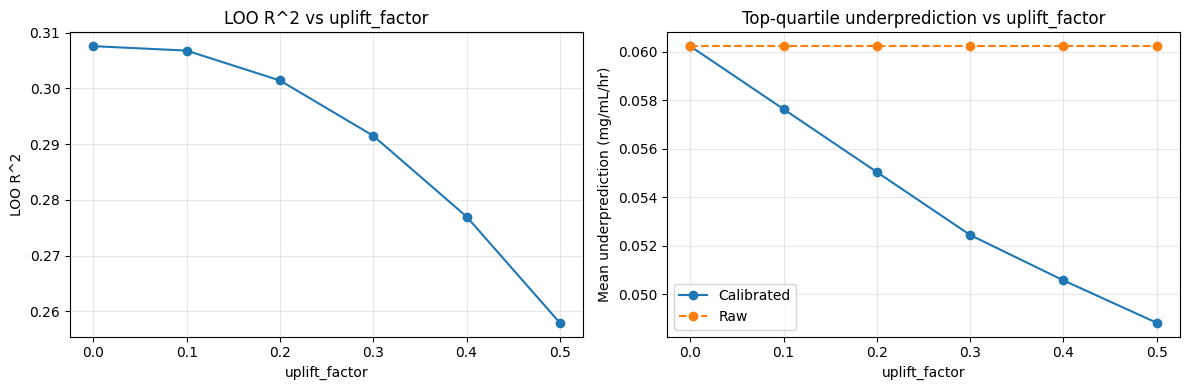

Selected uplift_factor=0.0 based on best LOO R^2 then lowest underprediction
Oracle trained with leave-one-out validation.
Rows: 49
Model: Bagged ridge (n_bags=5)
Alpha: 0.3 (auto_alpha=False)
Prediction calibration: upper_tail_uplift
  factor=0.0, quantile=0.75, threshold=0.1742
LOO metrics:   MAE=0.0545, RMSE=0.0754, R2=0.3076
Train metrics: MAE=0.0334, RMSE=0.0481, R2=0.7177
LOO predictions saved to: oracle_artifacts/loo_predictions.csv
Model saved to: oracle_artifacts/txtl_oracle_model.json
Restored oracle with selected uplift_factor=0.0


In [7]:
# 8) Sweep uplift_factor and plot R^2 vs high-end underprediction
import subprocess
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uplift_factors = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
rows = []

for uf in uplift_factors:
    cmd = [
        '.venv/bin/python',
        'train_txtl_oracle.py',
        '--bagging',
        '--alpha', '0.3',
        '--uplift-factor', str(uf),
    ]
    run = subprocess.run(cmd, capture_output=True, text=True)
    if run.returncode != 0:
        print(run.stdout)
        print(run.stderr)
        raise RuntimeError(f'Training failed for uplift_factor={uf}')

    with open('oracle_artifacts/txtl_oracle_model.json', 'r', encoding='utf-8') as f:
        model = json.load(f)

    loo_df = pd.read_csv('oracle_artifacts/loo_predictions.csv')
    q = loo_df['target_productivity_mg_mL_hr'].quantile(0.75)
    high = loo_df[loo_df['target_productivity_mg_mL_hr'] >= q]

    under_raw = float(np.mean(np.maximum(0.0, high['target_productivity_mg_mL_hr'] - high['predicted_productivity_raw_mg_mL_hr'])))
    under_cal = float(np.mean(np.maximum(0.0, high['target_productivity_mg_mL_hr'] - high['predicted_productivity_mg_mL_hr'])))

    rows.append({
        'uplift_factor': uf,
        'loo_r2': model['metrics_loo']['r2'],
        'loo_mae': model['metrics_loo']['mae'],
        'loo_rmse': model['metrics_loo']['rmse'],
        'top_quartile_underprediction_raw': under_raw,
        'top_quartile_underprediction_calibrated': under_cal,
    })

sweep_df = pd.DataFrame(rows).sort_values('uplift_factor')
display(sweep_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sweep_df['uplift_factor'], sweep_df['loo_r2'], marker='o')
axes[0].set_title('LOO R^2 vs uplift_factor')
axes[0].set_xlabel('uplift_factor')
axes[0].set_ylabel('LOO R^2')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['uplift_factor'], sweep_df['top_quartile_underprediction_calibrated'], marker='o', label='Calibrated')
axes[1].plot(sweep_df['uplift_factor'], sweep_df['top_quartile_underprediction_raw'], marker='o', linestyle='--', label='Raw')
axes[1].set_title('Top-quartile underprediction vs uplift_factor')
axes[1].set_xlabel('uplift_factor')
axes[1].set_ylabel('Mean underprediction (mg/mL/hr)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Select best by: highest R^2, then lowest high-end underprediction
best_row = sweep_df.sort_values(
    ['loo_r2', 'top_quartile_underprediction_calibrated'],
    ascending=[False, True],
).iloc[0]
best_uplift = float(best_row['uplift_factor'])
print(f'Selected uplift_factor={best_uplift} based on best LOO R^2 then lowest underprediction')

subprocess.run([
    '.venv/bin/python',
    'train_txtl_oracle.py',
    '--bagging',
    '--alpha', '0.3',
    '--uplift-factor', str(best_uplift),
], check=True)
print(f'Restored oracle with selected uplift_factor={best_uplift}')

In [8]:
# Oracle: what parameters maximize predicted productivity?
import json
import itertools
import numpy as np

model = json.load(open('oracle_artifacts/txtl_oracle_model.json'))
prep = model['preprocessor']
coeffs = np.array(model['coefficients'], dtype=float)
intercept = float(model['intercept'])
calibration = model.get('prediction_calibration')
numeric_features = model['numeric_features']
categorical_features = model['categorical_features']

# Parameter bounds
numeric_bounds = {
    'Mg_glutamate_mM': (4.0, 6.0),
    'K_glutamate_mM': (60.0, 80.0),
    'DTT_mM': (0.0, 3.0),
    'NTP_multiplier': (1.0, 3.0),
    'PEG_8000_percent': (0.0, 5.0),
    'temperature_C': [25, 30, 37],  # discrete
    'plasmid_concentration_nM': (5.0, 10.0),
}
categorical_options = {
    'energy_source': ['3-pga', '3-pga + maltose', '3-pga + maltodextrin'],
    'extract_type': ['wild-type', 'kc6'],
    'chaperones': ['none', 'groes/el', 'dnak/dnaj/grpe', 'combined'],
    'reaction_mode': ['batch', 'semi-continuous', 'microfluidic'],
}

def oracle_score(params):
    x = []
    for col in numeric_features:
        v = float(params[col])
        z = (v - prep['numeric_mean'][col]) / prep['numeric_std'][col]
        x.append(z)
    for col in categorical_features:
        v = str(params[col])
        for cat in prep['categories'][col]:
            x.append(1.0 if v == cat else 0.0)
    x = np.array(x)
    pred_raw = intercept + float(np.dot(x, coeffs))
    if calibration and calibration.get('method') == 'upper_tail_uplift':
        factor = float(calibration.get('factor', 0.0))
        threshold = float(calibration.get('threshold', 0.0))
        return pred_raw + factor * max(0.0, pred_raw - threshold)
    return pred_raw

# For each categorical combo + temperature, pick numeric bounds by coefficient sign
best_score = -np.inf
best_params = None
coeff_idx = 0
numeric_coeff_signs = {}
for col in numeric_features:
    numeric_coeff_signs[col] = coeffs[coeff_idx]
    coeff_idx += 1

cat_combos = list(itertools.product(*[categorical_options[c] for c in categorical_features]))
temp_values = numeric_bounds['temperature_C']

for cat_vals in cat_combos:
    cat_dict = dict(zip(categorical_features, cat_vals))
    for temp in temp_values:
        params = dict(cat_dict)
        params['temperature_C'] = temp
        for col in numeric_features:
            if col == 'temperature_C':
                continue
            lo, hi = numeric_bounds[col]
            params[col] = hi if numeric_coeff_signs[col] > 0 else lo
        score = oracle_score(params)
        if score > best_score:
            best_score = score
            best_params = dict(params)

print(f'Oracle-optimal predicted productivity: {best_score:.4f} mg/mL/hr\n')
print('Optimal parameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Oracle-optimal predicted productivity: 0.5184 mg/mL/hr

Optimal parameters:
  energy_source: 3-pga
  extract_type: kc6
  chaperones: combined
  reaction_mode: semi-continuous
  temperature_C: 25
  Mg_glutamate_mM: 6.0
  K_glutamate_mM: 60.0
  DTT_mM: 3.0
  NTP_multiplier: 1.0
  PEG_8000_percent: 0.0
  plasmid_concentration_nM: 5.0


# Debug


In [9]:
# One-off: print exactly what would be sent to the model for round 2
import json

# Requires `hypotheses` and `cross_check_results` from earlier cells.
iterator_preview = iterative_generation.TXTLHypothesisIterator(
    model=FREE_MODELS['gemini-2.5-flash'],
    verbose=False,
    use_oracle_fallback=True,
)

# Build round-1 context the same way production code does
iterator_preview.conversation_history = iterator_preview.build_round1_messages(
    num_hypotheses=len(hypotheses),
    context=None,
)

# Extract the exact round-2 payload from iterative_generation.py logic
round2_messages = iterator_preview.build_round2_messages(
    hypotheses=hypotheses,
    cross_check_results=cross_check_results,
    num_hypotheses=len(hypotheses),
)

print('=== ROUND 2 FULL MESSAGE PAYLOAD ===')
for i, msg in enumerate(round2_messages, start=1):
    print('')
    print(f"--- message {i} | role={msg['role']} ---")
    print(msg['content'])


NameError: name 'hypotheses' is not defined

In [ ]:
# 5) Optional: run one specific model loop manually
iterator, all_results = run_hypothesis_iterations(
    num_iterations=2,
    hypotheses_per_iteration=2,
    model=FREE_MODELS['gemini-2.5-flash'],
    context=None,
    use_oracle_fallback=True,
)
iterator.get_all_hypotheses_df().head(10)


In [ ]:
# 1) Generate hypotheses (single run)
hypotheses = generate_txtl_hypothesis(num_hypotheses=3, verbose=True)
hypotheses_to_dataframe(hypotheses)


[Model: upstage/solar-pro-3:free]


,hypothesis_name,Mg_glutamate_mM,K_glutamate_mM,DTT_mM,NTP_multiplier,energy_source,PEG_8000_percent,extract_type,temperature_C,chaperones,plasmid_concentration_nM,reaction_mode,estimated_productivity_mg_mL_hr,rationale
0,Mg 5 K 70 optimized,5.0,70,1,2.0,3-PGA,3,wild-type,30,GroES/EL,7,batch,0.35,Moderate Mg and K concentrations with GroES/EL...
1,Mg 4.5 K 65 maltose enhanced,4.5,65,2,1.5,3-PGA + maltose,4,wild-type,37,combined,9,microfluidic,0.55,High temperature combined with maltose energy ...
2,Mg 6 K 80 maltodextrin improved,6.0,80,0,3.0,3-PGA + maltodextrin,5,KC6,25,none,8,semi-continuous,0.70,Eliminating DTT and using KC6 extract with hig...


In [ ]:
# 2) Cross-check with experimental data + oracle fallback
cross_check_results = cross_check_hypotheses(
    hypotheses,
    verbose=True,
    use_oracle_fallback=True,
)
cross_check_results



Hypothesis: Mg 5 K 70 optimized
  Hypothesis params found: 11/11 - ['Mg_glutamate_mM', 'K_glutamate_mM', 'DTT_mM', 'NTP_multiplier', 'energy_source', 'PEG_8000_percent', 'extract_type', 'temperature_C', 'chaperones', 'plasmid_concentration_nM', 'reaction_mode']
  NO FULL MATCH in experimental dataset.
  ORACLE prediction: 0.117 mg/mL/hr

Hypothesis: Mg 4.5 K 65 maltose enhanced
  Hypothesis params found: 11/11 - ['Mg_glutamate_mM', 'K_glutamate_mM', 'DTT_mM', 'NTP_multiplier', 'energy_source', 'PEG_8000_percent', 'extract_type', 'temperature_C', 'chaperones', 'plasmid_concentration_nM', 'reaction_mode']
  NO FULL MATCH in experimental dataset.
  ORACLE prediction: 0.101 mg/mL/hr

Hypothesis: Mg 6 K 80 maltodextrin improved
  Hypothesis params found: 11/11 - ['Mg_glutamate_mM', 'K_glutamate_mM', 'DTT_mM', 'NTP_multiplier', 'energy_source', 'PEG_8000_percent', 'extract_type', 'temperature_C', 'chaperones', 'plasmid_concentration_nM', 'reaction_mode']
  NO FULL MATCH in experimental data

[{'hypothesis_name': 'Mg 5 K 70 optimized',
  'hypothesis': {'hypothesis_name': 'Mg 5 K 70 optimized',
   'Mg_glutamate_mM': 5.0,
   'K_glutamate_mM': 70,
   'DTT_mM': 1,
   'NTP_multiplier': 2,
   'energy_source': '3-PGA',
   'PEG_8000_percent': 3,
   'extract_type': 'wild-type',
   'temperature_C': 30,
   'chaperones': 'GroES/EL',
   'plasmid_concentration_nM': 7,
   'reaction_mode': 'batch',
   'estimated_productivity_mg_mL_hr': 0.35,
   'rationale': 'Moderate Mg and K concentrations with GroES/EL chaperones improve folding efficiency in a simple batch format.'},
  'matching_idxs': [],
  'near_matches': [],
  'experimental_productivity': {'has_data': False,
   'num_matches': 0,
   'matched_experiments': [],
   'min_productivity': None,
   'max_productivity': None,
   'avg_productivity': None},
  'oracle_prediction': {'available': True,
   'predicted_productivity_raw_mg_mL_hr': 0.11743737676520255,
   'predicted_productivity_mg_mL_hr': 0.11743737676520255,
   'model_type': 'ridge_reg

In [ ]:
# Run random LLM baseline (100 independent single-shot calls, no iterative context)
import numpy as np
import json

N_RANDOM = 100

_oracle_model_data = json.load(open('oracle_artifacts/txtl_oracle_model.json'))

random_scores = []
print(f"Running {N_RANDOM} independent single-shot LLM calls for random baseline...")
for i in range(N_RANDOM):
    score = np.nan
    try:
        hyps = generate_txtl_hypothesis(num_hypotheses=1, verbose=False)
        if hyps:
            pred = cross_check.oracle_predict_hypothesis(hyps[0], _oracle_model_data)
            if pred:
                score = float(pred['predicted_productivity_mg_mL_hr'])
    except Exception as e:
        print(f"  Call {i+1} failed: {e}")
    random_scores.append(score)
    if (i + 1) % 5 == 0:
        val_str = f"{score:.4f}" if not np.isnan(score) else "NaN"
        print(f"  {i+1}/{N_RANDOM} done, score: {val_str}")

valid = [s for s in random_scores if not np.isnan(s)]
print(f"\nValid calls: {len(valid)}/{N_RANDOM}")
print(f"Score range: [{min(valid):.4f}, {max(valid):.4f}], mean: {np.mean(valid):.4f}")

mean = np.mean(valid)
sem = np.std(valid, ddof=1) / np.sqrt(len(valid))
random_stats = {
    'n_calls': N_RANDOM,
    'scores': random_scores,
    'mean': mean,
    'ci95_lo': mean - 1.96 * sem,
    'ci95_hi': mean + 1.96 * sem,
}
print(f"Random baseline mean: {random_stats['mean']:.4f} mg/mL/hr, "
      f"95% CI: [{random_stats['ci95_lo']:.4f}, {random_stats['ci95_hi']:.4f}]")


Running 100 independent single-shot LLM calls for random baseline...
  5/100 done, score: 0.3917
  10/100 done, score: 0.3575
  15/100 done, score: 0.3517
  20/100 done, score: 0.1830
  25/100 done, score: 0.3575
  30/100 done, score: 0.1786
  35/100 done, score: 0.3770
  40/100 done, score: 0.3480
  45/100 done, score: 0.1230
  50/100 done, score: 0.3540
  55/100 done, score: 0.1803
  60/100 done, score: 0.2063
  65/100 done, score: 0.3865
  70/100 done, score: 0.3485
  75/100 done, score: 0.3575
  80/100 done, score: 0.3562
  85/100 done, score: 0.3580
  90/100 done, score: 0.3429
  95/100 done, score: 0.3795
  100/100 done, score: 0.3860

Valid calls: 100/100
Score range: [0.0797, 0.3944], mean: 0.2912
Random baseline mean: 0.2912 mg/mL/hr, 95% CI: [0.2706, 0.3118]
